# 8.10 — Decoding task variables from SC pseudo-populations (logistic)

Decode **`abs_coherence`** (evidence strength), **`choice`** (toRF/awayRF direction), and
**`hmm_state`** (biased/unbiased prior state) from SC pseudo-population activity, time-resolved
across the four task epochs, fit **separately** for toRF and awayRF prior sessions, **correct
trials only**.

Method follows Zhang et al. (bioRxiv 2025.12.31.697231) §5.7-5.9:
- **Decoder** = single linear layer, `BatchNorm -> Dropout(0.5) -> Linear`, cross-entropy, Adam
  (softmax lives in the loss; argmax over logits at test).
- **Input** = 50 ms smoothed firing rate (mean of `convolved_spike_trains` per 50 ms bin).
- **Sampling** = per session, per class: real-trial 80/20 split, then bootstrap with replacement
  to 800 train / 200 test **per class**; sessions stacked neuron-wise (pseudo-population).
- **8** train/test repeats -> mean +/- SEM. One decoder per (variable, epoch, time bin).
- Correct trials with **RT < 250 ms are rejected** (QC nb 8.00 shows this is not coherence-dependent:
  Cramer's V < 0.03, class shares move <=0.2pp). This lets the RT-limited stimulus-aligned (cue) and
  response epochs reach the decision period. Per-alignment bins are then trimmed to the NaN-free
  window (NaN begins at RT-50 due to `alignment_buffer=50`); baseline/visual use their full window.

Outputs (both in `processed/decoder/`): `decoding_results_8.10.pkl` (accuracy over time) and
`decoding_models_8.10.pkl` (trained decoder state_dicts + train/test splits per repeat, for Goal 2).


In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import pickle
import numpy as np
import torch
import torch.nn as nn

from imports import *  # Path, np, pd, plt
from config import dir_config, ephys_config
from src.utils import decoding_utils


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/HONGYE/opt/anaconda3/envs/prior-sc/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/HONGYE/opt/anaconda3/envs/prior-sc/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/Users/HONGYE/opt/anaconda3/envs/prior-sc/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/HONGYE/opt/anaconda3/envs/prior-sc/lib/python3.11/site-packages/traitlets/con

In [3]:
processed_dir = Path(dir_config.data.processed)
GP_CONFIG        = ephys_config["alignment_settings_GP"]
alignments    = list(GP_CONFIG.keys())          # ['baseline', 'visual', 'cue', 'response']
device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "| alignments:", alignments)

session_to_exclude = ["210210_GP_JP", "241209_GP_TZ"]

session_metadata = pd.read_csv(processed_dir / "sessions_metadata.csv")
session_metadata = session_metadata[~session_metadata.session_id.isin(session_to_exclude)].reset_index(drop=True)

neuron_metadata = pd.read_csv(processed_dir / "neuron_metadata.csv")
neuron_metadata = neuron_metadata[~neuron_metadata.session_id.isin(session_to_exclude)].reset_index(drop=True)

with open(processed_dir / "glm_hmm_models" / "glm_hmm_masked_final.pkl", "rb") as f:
    glm_hmm = pickle.load(f)
# ephys_neuron_wise.pkl (3 GB) is loaded lazily in the decode cell, only when actually decoding

device: cpu | alignments: ['baseline', 'visual', 'cue', 'response']


In [4]:
# --- trial info (toRF reference frame; carries prior_direction) -> correct-only + abs_coherence ---
trial_info_all = decoding_utils.prepare_trial_info(session_metadata, glm_hmm)
print("prior_direction counts:", dict(trial_info_all.prior_direction.value_counts()))

# GUARD: choice == 1 must mean toRF. In biased blocks at 0% coherence, toRF sessions should
# choose toRF (>0.5) and awayRF sessions should choose away (<0.5).
def choice_bias(direction):
    subset = trial_info_all[(trial_info_all.prior_direction == direction)
                            & (trial_info_all.signed_coherence == 0)
                            & (trial_info_all.prior_block == 1)]
    return subset.choice.mean()
mean_choice_toRF, mean_choice_awayRF = choice_bias("toRF"), choice_bias("awayRF")
print(f"biased-block 0%-coh mean(choice=1/toRF): toRF={mean_choice_toRF:.3f} (>0.5)  awayRF={mean_choice_awayRF:.3f} (<0.5)")
assert mean_choice_toRF > 0.5 and mean_choice_awayRF < 0.5, "choice coding is NOT toRF=1 -- investigate before decoding!"

RT_TRIM_MS = 250  # reject fast trials so cue/response epochs reach the decision period; QC: nb 8.00
trial_info = trial_info_all[trial_info_all.outcome == 1].reset_index(drop=True)  # correct only
trial_info = trial_info[trial_info.reaction_time >= RT_TRIM_MS].reset_index(drop=True)
trial_info["abs_coherence"] = trial_info.signed_coherence.abs()
print(f"correct + RT>={RT_TRIM_MS}ms trials: {len(trial_info)}")
print("abs_coherence levels:", np.sort(trial_info.abs_coherence.unique()))
print("choice classes:", np.sort(trial_info.choice.unique()),
      "| hmm_state classes:", np.sort(trial_info.hmm_state.unique()))

prior_direction counts: {'toRF': np.int64(23939), 'awayRF': np.int64(18528)}
biased-block 0%-coh mean(choice=1/toRF): toRF=0.650 (>0.5)  awayRF=0.318 (<0.5)
correct + RT>=250ms trials: 31961
abs_coherence levels: [0.   0.06 0.2  0.5 ]
choice classes: [0 1] | hmm_state classes: [0 1]


In [5]:
# --- decoder model (paper 5.8): BatchNorm -> Dropout -> Linear ---
class LinearDecoder(nn.Module):
    """Single linear layer with input BatchNorm + dropout = regularized multinomial logistic."""
    def __init__(self, n_input, n_classes, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(n_input),
            nn.Dropout(dropout),
            nn.Linear(n_input, n_classes),
        )
    def forward(self, x):
        return self.net(x)


def fit_decoder(X_train, y_train, X_test, y_test, n_classes,
                n_epochs=200, lr=1e-3, dropout=0.5, device="cpu", return_model=False):
    """Train LinearDecoder (cross-entropy applies softmax internally); return test accuracy (argmax).

    If return_model=True, also return the trained model's cpu state_dict (weights + BatchNorm
    running stats), so it can be reloaded and reused for cross-temporal / cross-variable decoding.
    """
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32, device=device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long,    device=device)
    X_test_tensor  = torch.tensor(X_test,  dtype=torch.float32, device=device)
    y_test_tensor  = torch.tensor(y_test,  dtype=torch.long,    device=device)

    model     = LinearDecoder(X_train.shape[1], n_classes, dropout=dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    model.train()
    for _ in range(n_epochs):
        optimizer.zero_grad()
        criterion(model(X_train_tensor), y_train_tensor).backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        accuracy = (model(X_test_tensor).argmax(1) == y_test_tensor).float().mean().item()
    if return_model:
        state_dict = {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}
        return accuracy, state_dict
    return accuracy

In [6]:
# --- NaN-free binning: keep only 50 ms bins with no NaN across ALL trials/neurons ---
def alignment_valid_mask(session_data_event):
    """Boolean (n_timebins,): True where NO trial/neuron is NaN across all sessions."""
    masks = []
    for session in session_data_event.values():
        masks.append(~np.isnan(session["spikes"]).any(axis=(0, 1)))  # (n_timebins,)
    return np.all(masks, axis=0) if masks else None


def compute_bins(alignment, valid_mask, bin_size=50):
    """Return [(t0,t1), ...] index-space bins that are fully NaN-free, and their centre times (ms)."""
    start_ms = GP_CONFIG[alignment]["start_time_ms"]
    T = len(valid_mask)
    edges, centres = [], []
    for t in range(0, T - bin_size + 1, bin_size):
        if valid_mask[t:t + bin_size].all():
            edges.append((t, t + bin_size))
            centres.append(start_ms + t + bin_size // 2)
    return edges, np.array(centres)

In [7]:
# --- core: time-resolved pseudo-population decoding for one variable x one alignment ---
def decode_pseudo_population(session_data_event, label_col, label_values, neuron_positions,
                             n_total_neurons, bin_edges,
                             n_train=800, n_test=200, n_repeats=8, test_size=0.2,
                             n_epochs=200, lr=1e-3, dropout=0.5, device="cpu", seed0=0,
                             save_models=False, n_shuffles=10):
    """Returns (repeat_accs (n_repeats, n_bins), mean_acc, sem_acc, null_accs (n_shuffles, n_bins), fitted).

    real : n_repeats 80/20 real-trial splits (one split per repeat, reused across all bins) -> mean +/- SEM.
    null : n_shuffles WITHIN-SESSION label permutations, same decode -> full null_accs array; the plot
           z-tests real vs this shuffle distribution per bin (Fig 5b: thickness-coded significance bar).
    fitted (if save_models): trained model state_dict + train/test split per real repeat (Goal 2).
    Sessions lacking any class are dropped (their columns stay 0 = constant = harmless).
    """
    n_classes = len(label_values)
    n_bins    = len(bin_edges)
    eligible_sessions = [session_id for session_id, session in session_data_event.items()
                         if all((session[label_col] == class_value).sum() > 0 for class_value in label_values)]

    def run_repeat(labels_by_session, rng, collect_model=False):
        """One 80/20 split + bootstrap on the GIVEN labels, decode every bin.
        Returns (accs (n_bins,), models {bin_idx: state_dict} or None, (train_idx, test_idx))."""
        train_idx, test_idx = {}, {}
        for class_idx, class_value in enumerate(label_values):
            for session_id in eligible_sessions:
                n_trials = int((labels_by_session[session_id] == class_value).sum())
                perm = rng.permutation(n_trials)
                n_test_pool = max(1, int(n_trials * test_size))
                if n_test_pool >= n_trials:               # too few trials -> bootstrap all for both
                    train_pool = test_pool = np.arange(n_trials)
                else:
                    test_pool, train_pool = perm[:n_test_pool], perm[n_test_pool:]
                train_idx[(class_idx, session_id)] = rng.choice(train_pool, n_train, replace=True)
                test_idx[(class_idx, session_id)]  = rng.choice(test_pool,  n_test,  replace=True)
        accs = np.zeros(n_bins)
        models = {} if collect_model else None
        for bin_idx, (t0, t1) in enumerate(bin_edges):
            X_train = np.zeros((n_classes * n_train, n_total_neurons))
            X_test  = np.zeros((n_classes * n_test,  n_total_neurons))
            for class_idx, class_value in enumerate(label_values):
                train_start, test_start = class_idx * n_train, class_idx * n_test
                for session_id in eligible_sessions:
                    class_mask = labels_by_session[session_id] == class_value
                    binned_rate = session_data_event[session_id]["spikes"][class_mask][:, :, t0:t1].mean(-1)
                    session_columns = neuron_positions[session_id]
                    X_train[train_start:train_start + n_train, session_columns] = binned_rate[train_idx[(class_idx, session_id)]]
                    X_test[test_start:test_start + n_test,     session_columns] = binned_rate[test_idx[(class_idx, session_id)]]
            y_train = np.repeat(np.arange(n_classes), n_train)
            y_test  = np.repeat(np.arange(n_classes), n_test)
            if collect_model:
                accs[bin_idx], models[bin_idx] = fit_decoder(X_train, y_train, X_test, y_test, n_classes,
                                                             n_epochs=n_epochs, lr=lr, dropout=dropout,
                                                             device=device, return_model=True)
            else:
                accs[bin_idx] = fit_decoder(X_train, y_train, X_test, y_test, n_classes,
                                            n_epochs=n_epochs, lr=lr, dropout=dropout, device=device)
        return accs, models, (train_idx, test_idx)

    true_labels = {session_id: session_data_event[session_id][label_col] for session_id in eligible_sessions}

    # --- real decode ---
    fitted = {"models": {}, "splits": {}, "eligible_sessions": eligible_sessions} if save_models else None
    repeat_accs = np.zeros((n_repeats, n_bins))
    for repeat_idx in range(n_repeats):
        rng = np.random.default_rng(seed0 + repeat_idx)
        accs, models, (train_idx, test_idx) = run_repeat(true_labels, rng, collect_model=save_models)
        repeat_accs[repeat_idx] = accs
        if save_models:
            for bin_idx, state_dict in models.items():
                fitted["models"][(repeat_idx, bin_idx)] = state_dict
            fitted["splits"][repeat_idx] = {
                "train_idx": {key: idx.astype(np.int32) for key, idx in train_idx.items()},
                "test_idx":  {key: idx.astype(np.int32) for key, idx in test_idx.items()},
            }

    # --- shuffled null (within-session label permutation) ---
    null_accs = np.zeros((n_shuffles, n_bins))
    for shuffle_idx in range(n_shuffles):
        rng = np.random.default_rng(seed0 + 10_000 + shuffle_idx)
        shuffled_labels = {session_id: rng.permutation(true_labels[session_id]) for session_id in eligible_sessions}
        null_accs[shuffle_idx], _, _ = run_repeat(shuffled_labels, rng, collect_model=False)

    return repeat_accs, repeat_accs.mean(0), repeat_accs.std(0) / np.sqrt(n_repeats), null_accs, fitted

In [8]:
# --- hyperparameters ---
N_TRAIN, N_TEST, N_REPEATS = 800, 200, 8   # per class (paper 5.7-5.8; user-chosen 800/200)
BIN_SIZE  = 50
N_EPOCHS  = 200
LR        = 1e-3
DROPOUT   = 0.5
N_SHUFFLES = 10      # within-session label-shuffle null (paper-style baseline, replaces 1/K line)
SAVE_MODELS = True   # also persist trained decoders + train/test splits for cross-temporal / cross-variable (Goal 2)
FORCE_RERUN = False  # if the results pkl exists, skip the ~20-min decode and just reload it (set True to recompute)
decode_variables = ["abs_coherence", "choice", "hmm_state"]

In [9]:
# --- decode (or reload if already computed): {direction} x {variable} x {alignment} ---
decoder_dir = processed_dir / "decoder"
decoder_dir.mkdir(parents=True, exist_ok=True)
results_path = decoder_dir / "decoding_results_8.10.pkl"
if not FORCE_RERUN and results_path.exists():
    with open(results_path, "rb") as f:
        results = pickle.load(f)
    print(f"loaded existing {results_path.name} (set FORCE_RERUN=True to recompute)")
else:
    with open(processed_dir / "ephys_neuron_wise.pkl", "rb") as f:   # 3 GB, loaded only when decoding
        ephys_data = pickle.load(f)
    results, saved_models = {}, {}
    for direction in ["toRF", "awayRF"]:
        direction_trial_info = trial_info[trial_info.prior_direction == direction].reset_index(drop=True)
        sessions = sorted(direction_trial_info.session_id.unique())
        session_data, neuron_positions, n_total_neurons, label_values = decoding_utils.get_session_trial_data(
            sessions, direction_trial_info, neuron_metadata, ephys_data, alignments)
        print(f"\n=== {direction}: {n_total_neurons} neurons across {len(neuron_positions)} sessions ===")
        results[direction] = {"n_total_neurons": n_total_neurons, "label_values": label_values, "decode": {}}
        saved_models[direction] = {"n_input": n_total_neurons, "sessions": sessions,
                                   "neuron_positions": neuron_positions, "decode": {}}
        for variable in decode_variables:
            results[direction]["decode"][variable] = {}
            saved_models[direction]["decode"][variable] = {}
            for alignment in alignments:
                valid_mask = alignment_valid_mask(session_data[alignment])
                edges, centres = compute_bins(alignment, valid_mask, BIN_SIZE)
                _, mean_acc, sem, null_accs, fitted = decode_pseudo_population(
                    session_data[alignment], variable, label_values[variable], neuron_positions, n_total_neurons, edges,
                    n_train=N_TRAIN, n_test=N_TEST, n_repeats=N_REPEATS, n_shuffles=N_SHUFFLES,
                    n_epochs=N_EPOCHS, lr=LR, dropout=DROPOUT, device=str(device), save_models=SAVE_MODELS)
                results[direction]["decode"][variable][alignment] = {"centres": centres, "mean": mean_acc, "sem": sem, "null": null_accs}
                if SAVE_MODELS:
                    saved_models[direction]["decode"][variable][alignment] = {
                        "bin_edges": edges, "centres": centres, "n_classes": len(label_values[variable]),
                        "label_values": label_values[variable], "fitted": fitted,
                    }
    with open(results_path, "wb") as f:
        pickle.dump(results, f)
    print(f"\nsaved {results_path.name}")
    if SAVE_MODELS:
        model_bundle = {
            "models": saved_models,
            "hyperparams": {"n_train": N_TRAIN, "n_test": N_TEST, "n_repeats": N_REPEATS,
                            "dropout": DROPOUT, "bin_size": BIN_SIZE, "seed0": 0},
            "decoder_arch": "BatchNorm1d(n_input) -> Dropout(0.5) -> Linear(n_input, n_classes)",
        }
        with open(decoder_dir / "decoding_models_8.10.pkl", "wb") as f:
            pickle.dump(model_bundle, f)
        print("saved decoder/decoding_models_8.10.pkl (state_dicts + train/test splits for Goal 2)")


=== toRF: 74 neurons across 24 sessions ===

=== awayRF: 68 neurons across 19 sessions ===

saved decoding_results_8.10.pkl
saved decoder/decoding_models_8.10.pkl (state_dicts + train/test splits for Goal 2)


===== toRF   (sig bar: thick p<.001, medium p<.01, thin p<.05) =====


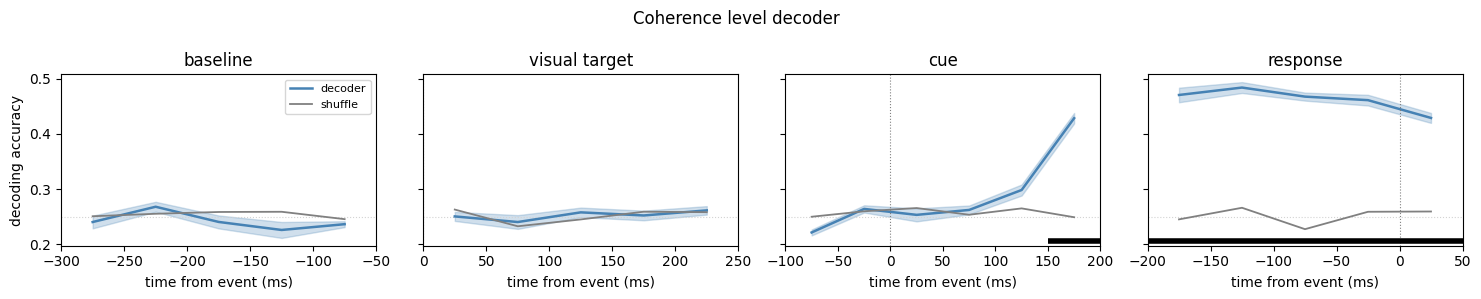

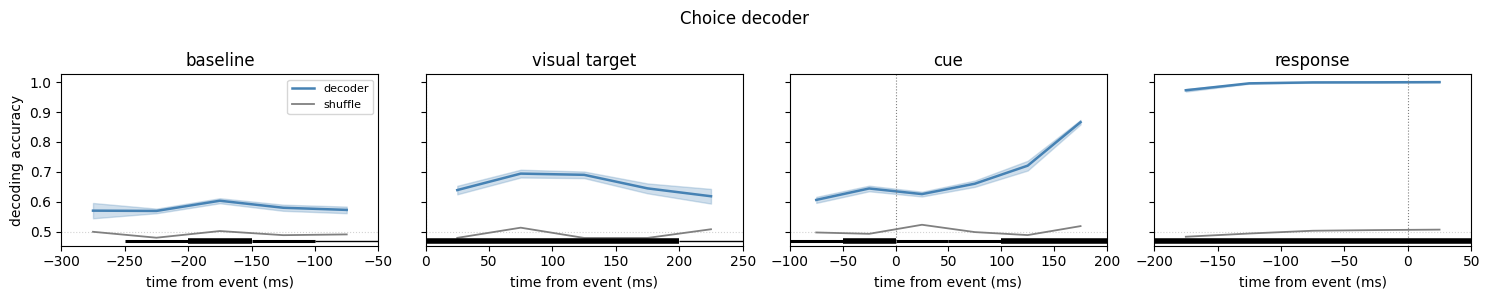

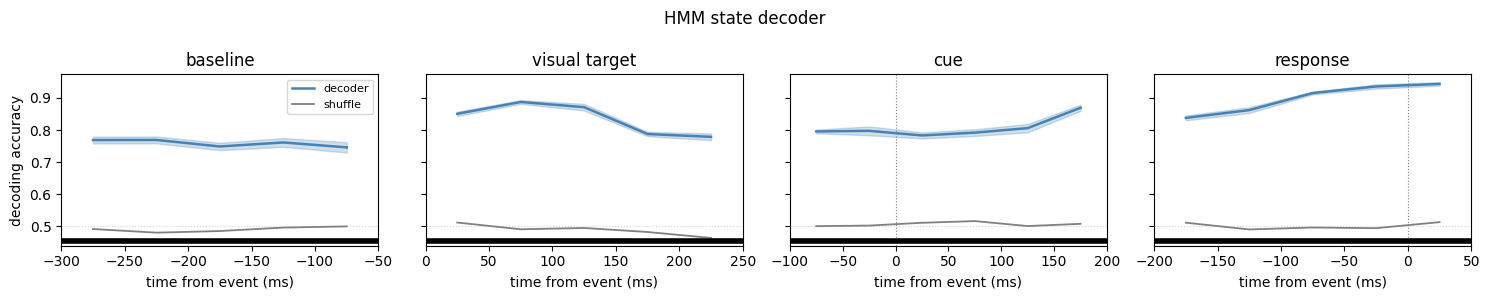

===== awayRF   (sig bar: thick p<.001, medium p<.01, thin p<.05) =====


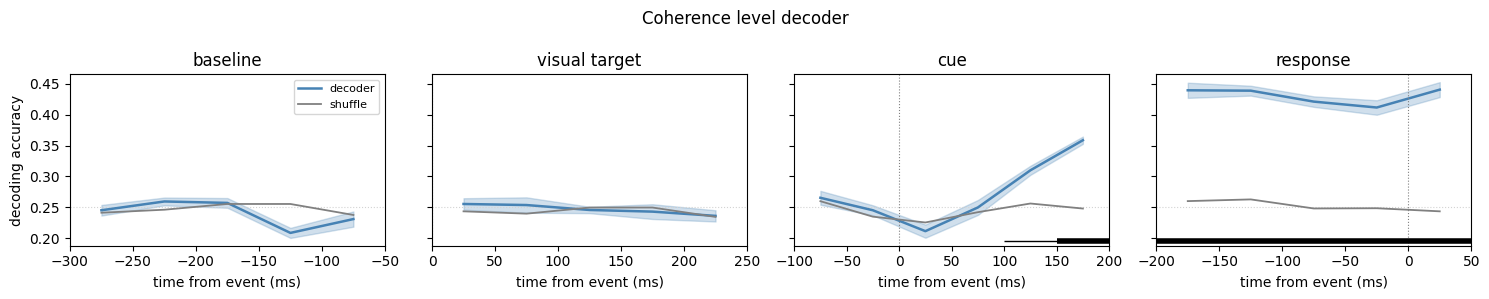

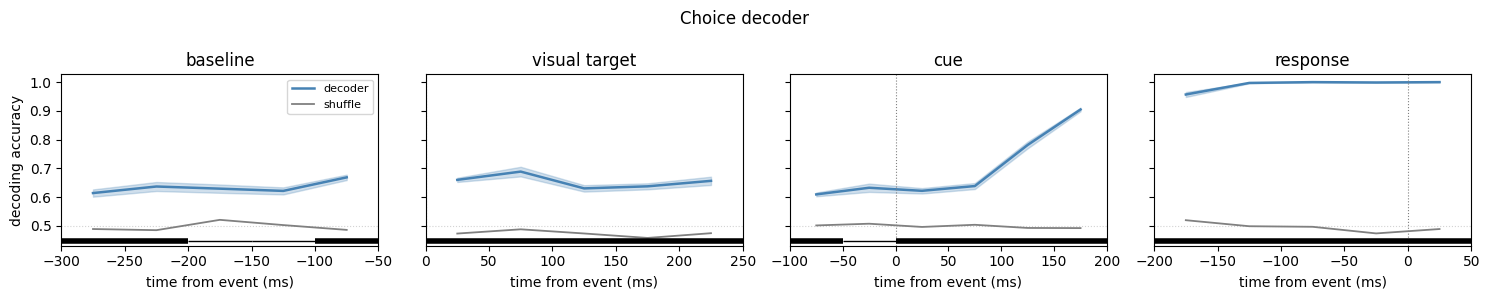

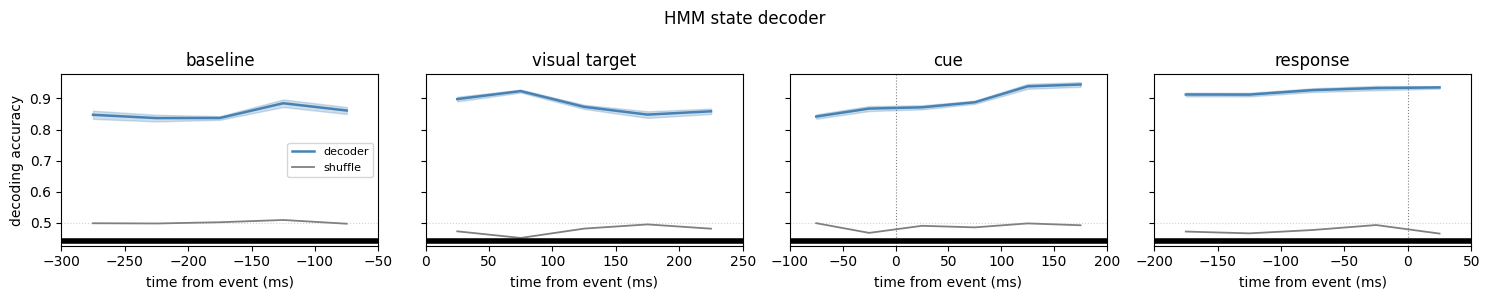

In [10]:
# --- plot: accuracy over time + shuffle-null line + significance bars (Fig 5b style) ---
from scipy.stats import norm
variable_titles = {"abs_coherence": "Coherence level decoder", "choice": "Choice decoder", "hmm_state": "HMM state decoder"}
epoch_titles    = {"baseline": "baseline", "visual": "visual target", "cue": "cue", "response": "response"}
# significance bar thickness by p (z-test of real accuracy vs the shuffle-null distribution)
def sig_lw(p):
    return 4.0 if p < 0.001 else 2.2 if p < 0.01 else 1.0 if p < 0.05 else 0.0
for direction in results:
    print(f"===== {direction}   (sig bar: thick p<.001, medium p<.01, thin p<.05) =====")
    for variable, aligns in results[direction]["decode"].items():
        chance = 1.0 / len(results[direction]["label_values"][variable])
        fig, axes = plt.subplots(1, len(aligns), figsize=(15, 3), sharey=True)
        for ax, (alignment, data) in zip(axes, aligns.items()):
            centres, mean_acc, sem, null_accs = data["centres"], data["mean"], data["sem"], data["null"]
            half = (centres[1] - centres[0]) / 2 if len(centres) > 1 else 25
            ax.axhline(chance, ls=":", c="lightgray", lw=0.8)
            ax.fill_between(centres, mean_acc - sem, mean_acc + sem, alpha=0.25, color="steelblue")
            ax.plot(centres, mean_acc, color="steelblue", lw=1.8, label="decoder")
            ax.axvline(0, ls=":", c="gray", lw=0.8)
            if null_accs.shape[0] > 0:                                   # shuffle null computed (step 3)
                null_mean, null_std = null_accs.mean(0), null_accs.std(0) + 1e-9
                pvals = norm.sf((mean_acc - null_mean) / null_std)      # one-sided z-test vs shuffle null
                ax.plot(centres, null_mean, color="gray", lw=1.3, label="shuffle")
                for xc, p in zip(centres, pvals):
                    lw = sig_lw(p)
                    if lw:
                        ax.hlines(0.03, xc - half, xc + half, transform=ax.get_xaxis_transform(), color="k", lw=lw)
            ax.set_xlim(centres[0] - half, centres[-1] + half)
            ax.set_title(epoch_titles.get(alignment, alignment))
            ax.set_xlabel("time from event (ms)")
        axes[0].set_ylabel("decoding accuracy")
        axes[0].legend(fontsize=8, loc="best")
        fig.suptitle(variable_titles.get(variable, variable))
        plt.tight_layout(); plt.show()